In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import json
from matplotlib.pyplot import text

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42


matplotlib.rcParams['font.size'] = 18
# matplotlib.rcParams['font.size'] = 16ho

import re
import time
import subprocess
import os
import signal


In [2]:
import sys
sys.path.append('./helpers')

In [3]:
import importlib
from backend_helpers import *
from kernel_metrics import *
from benchmark_data import *
from visualisation import *



In [4]:
%load_ext autoreload
%autoreload 2

# Pre-flight checks

In [5]:
backend_endpoint ="127.0.0.1:5000"

In [14]:
run_host_script(script="setup_patch_clean_cfs.sh")

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #3
ktime                                   : 265048.026812
sched_clk                               : 264820.588364
cpu_clk                                 : 264788.255184
jiffies                                 : 4294958519
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0

In [7]:
run_host_script(script="setup_patch_clean_systemd_cgroupv2.sh")

kernel.sched_disable_calc_group_shares = 1
kernel.sched_disable_vruntime_preemption = 1
-----
kernel.sched_entity_before_policy = 1
kernel.sched_check_preempt_wakeup_latency_awareness = 100
kernel.sched_cpu_has_higher_load_task = 100
-----
kernel.sched_tg_load_avg_ema = 1
kernel.sched_tg_load_avg_ema_window = 1000
-----
setting default shares
/sys/fs/cgroup/*/cpu.weight
/sys/fs/cgroup/*/*/cpu.weight
1024
1024
--------
resetting latency awawreness flags
/sys/fs/cgroup/*/cpu.latency_awareness
/sys/fs/cgroup/*/*/cpu.latency_awareness
0
0
-----
setting latency awawreness flags
/sys/fs/cgroup/faas.slice/*/cpu.latency_awareness
1
--------



In [8]:
reset_shares_cfs()
# reset_shares_llf_static()

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #3
ktime                                   : 105562.703567
sched_clk                               : 105337.511906
cpu_clk                                 : 105305.178708
jiffies                                 : 4294918647
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0

# Kernel metrics

In [9]:
    
a = schedstat_domains_snapshot()
time.sleep(10)
b = schedstat_domains_snapshot()

(b.astype(int) - a.astype(int)).sum(axis=1)


0     12716
1     12517
2       195
3       277
4      2503
5         0
6        23
7     12491
8       263
9       263
10        0
11        0
12        0
13        0
14        0
15      263
16    26011
17    18104
18     7040
19    11628
20      867
21        0
22     3580
23    14522
24     2499
25        1
26     2498
27        0
28        0
29        0
30        0
31        0
32        0
33    69103
34    47815
35        0
dtype: int64

In [10]:

a = schedstat_snapshot()
b = schedstat_snapshot()

display((b.astype(int) - a.astype(int)).sum())

nr_switches_start = nr_switches_snapshot()

# time.sleep(10)
nr_switches_end = nr_switches_snapshot()

display((nr_switches_end - nr_switches_start).sum())
    

yield                         92
schedule                     984
idle                         441
try_to_wake_up               444
try_to_wake_up local          19
tasks_running           43764511
tasks_waiting             229253
timeslices                   451
dtype: int64

nr_switches    1490
dtype: int64

# Preparing files

In [33]:

    
rd_hashd_benchmark_args_workload(workload='none',functions=400)    

['//"trace_path": "/local/scratch/rd-hashd/none/trace-991",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-992",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-993",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-994",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-995",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-996",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-997",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-998",', '//"trace_path": "/local/scratch/rd-hashd/none/trace-999",', '']


# Parameter space

In [16]:
!cat /local/scratch/CFS-LLF_main/rd-hashd/params.json | grep '\/\/'

# //
# // rd-hashd runtime parameters
# //
# // All parameters can be updated while running and will be applied immediately.
# //
# // rd-hashd keeps calculating SHA1s of different parts of testfiles using
# // concurrent worker threads. The testfile indices and hash sizes are
# // determined using truncated normal distributions which gradually transforms
# // to uniform distributions as their standard deviations increase.
# //
# // All durations are in seconds and memory bytes. A _frac field should be <=
# // 1.0 and specifies a sub-proportion of some other value. A _ratio field is
# // similar but may be greater than 1.0.
# //
# // The concurrency level is modulated using two PID controllers to target the
# // specified latency and RPS so that neither is exceeded. The total number
# // of concurrent threads is limited by `concurrency_max`.
# //
# // The total size of testfiles is set up during startup and can't be changed
# // online. However, the portion which is actively used by rd

## Parameter space - independent values

In [17]:
!cat /local/scratch/CFS-LLF_main/rd-hashd/params.json  | grep -v '\/\/\|lat_target\|sleep\|concurrency'

{
  "control_period": 1.0,
  "rps_target": 65536,
  "rps_max": 1000,
  "mem_frac": 0.001,
  "chunk_pages": 25,
  "file_frac": 0.25,
  "file_size_mean": 377487,
  "file_size_stdev_ratio": 0.45,
  "file_addr_stdev_ratio": 0.215,
  "file_addr_rps_base_frac": 0.5,
  "file_write_frac": 0.0,
  "anon_size_ratio": 2.3,
  "anon_size_stdev_ratio": 0.45,
  "anon_addr_stdev_ratio": 0.235,
  "anon_addr_rps_base_frac": 0.5,
  "anon_write_frac": 0.3,
  "cpu_ratio": 0.93,
  "log_bps": 1100794,
  "fake_cpu_load": false,
  "acc_dist_slots": 0,
  "lat_pid": {
    "kp": 0.1,
    "ki": 0.01,
    "kd": 0.01
  },
  "rps_pid": {
    "kp": 0.25,
    "ki": 0.01,
    "kd": 0.01
  }
}


## Parameter space - tuned values

In [18]:
!cat /local/scratch/CFS-LLF_main/rd-hashd/params.json  | grep 'lat_target\|sleep\|concurrency'

# // The concurrency level is modulated using two PID controllers to target the
# // of concurrent threads is limited by `concurrency_max`.
# // Worker threads will sleep according to the sleep duration distribution and
# //  concurrency_max: Maximum number of worker threads
# //  lat_target_pct: Latency target percentile
# //  lat_target: Latency target
# //  sleep_mean: Worker sleep duration average
# //  sleep_stdev_ratio: Standard deviation of sleep duration distribution
  "concurrency_max": 65536,
  "lat_target_pct": 0.5,
  "lat_target": 0.1,
  "sleep_mean": 0.02,
  "sleep_stdev_ratio": 0.33,


# Experiment code

In [11]:

    
enable_schedstats()    

kernel.sched_schedstats = 1



# Results (no special kernel metrics)

In [12]:
density_range = [x for x in range(12, 12*20, 12*4)]


In [25]:
density_range = [12, 120, 228]
results_resctl_cfs = {}
results_resctl_cfsllf = {}
results_resctl_cfstuned = {}

In [26]:
!sudo cp ../rd-hashd/rd-hashd /usr/local/bin/rd-hashd

print(density_range)

for x in density_range: 
    results_resctl_cfs[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_cfs.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)


print(density_range)

for x in density_range: 
    results_resctl_cfsllf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_systemd.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)

print(density_range)

for x in density_range: 
    results_resctl_cfstuned[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_cfs_tuned.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)

[12, 120, 228]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #3
ktime                                   : 805319.360466
sched_clk                               : 805087.505742
cpu_clk                                 : 805055.172550
jiffies                                 : 4295093586
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latenc

nr_switches    2956824
dtype: int64

yield                          1248021
schedule                       3737330
idle                             15635
try_to_wake_up                 1447622
try_to_wake_up local            897890
tasks_running            3200355016578
tasks_waiting           13542092797716
timeslices                     2941301
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #3
ktime                                   : 922586.056325
sched_clk                               : 922351.947663
cpu_clk                                 : 922319.614481
jiffies                                 : 4295122903
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness = 0

nr_switches    4401980
dtype: int64

...

nr_switches    2485686
dtype: int64

yield                          1549148
schedule                       3264117
idle                              2496
try_to_wake_up                 1042669
try_to_wake_up local            807855
tasks_running            3204574789389
tasks_waiting           32712390398553
timeslices                     2482759
dtype: int64

vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #3
ktime                                   : 1805613.116105
sched_clk                               : 1805373.851192
cpu_clk                                 : 1805341.517996
jiffies                                 : 4295343660
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awareness 

nr_switches    2848189
dtype: int64

yield                          2465279
schedule                       4324185
idle                              2628
try_to_wake_up                 1130100
try_to_wake_up local            882222
tasks_running            3204823034354
tasks_waiting           35460518439447
timeslices                     2846079
dtype: int64

In [16]:
!mkdir pickled-new

In [17]:
sort_dict_by_keys = lambda d: {key: d[key] for key in sorted(d)}

In [27]:
import pickle

def dump_vars(experiments):
    
    for key,val in experiments:
        print(key)
        file_dump = open(f'pickled-new/{key}', 'wb')
        pickle.dump(val, file_dump)
        file_dump.close()

In [28]:
variables = [
    ('results_resctl_cfs',results_resctl_cfs),
    ('results_resctl_cfsllf',results_resctl_cfsllf),
    ('results_resctl_cfstuned',results_resctl_cfstuned)
]

dump_vars(variables)


results_resctl_cfs
results_resctl_cfsllf
results_resctl_cfstuned


91.125 468.49449999999985
91.125 468.49449999999985
84.79 444.62649999999996
91.125 468.49449999999985
55.93 932.82
62.65 1057.4389999999996
91.125 468.49449999999985
54.13 1242.7244999999998
55.72 1502.7019999999982


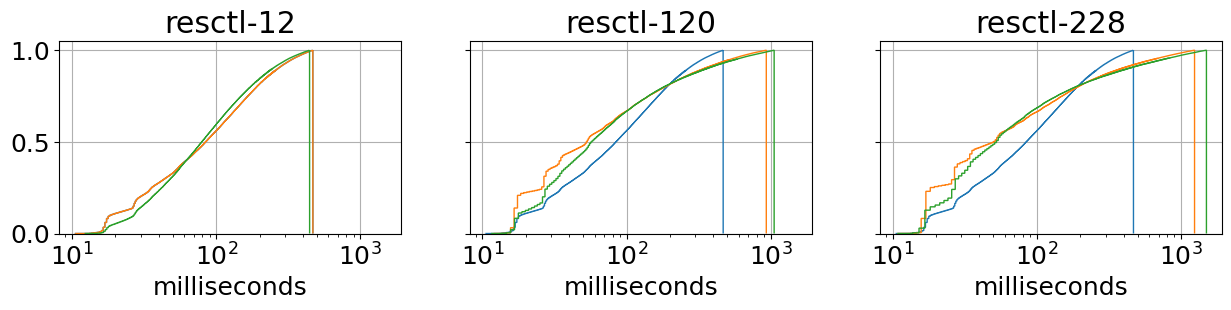

In [30]:
fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_resctl_cfstuned, results_resctl_cfsllf,fig,ax[0],'resctl-12',12,density=1)
visualise_latency_cdf(results_resctl_cfstuned, results_resctl_cfsllf,fig,ax[1],'resctl-120',120,density=1)
visualise_latency_cdf(results_resctl_cfstuned, results_resctl_cfsllf,fig,ax[2],'resctl-228',228,density=1)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,30000)



In [33]:
!diff --color ./../scripts/setup_patch_clean_cfs.sh ./../scripts/setup_patch_clean_cfs_tuned.sh 

6,7c6,7
< echo '24000000' | sudo tee -a /sys/kernel/debug/sched/latency_ns
< echo '3000000' | sudo tee -a /sys/kernel/debug/sched/min_granularity_ns
---
> echo '1000000000' | sudo tee -a /sys/kernel/debug/sched/latency_ns
> echo '100000000' | sudo tee -a /sys/kernel/debug/sched/min_granularity_ns


100.05 220.09
100.05 220.09
84.79 444.62649999999996
100.05 220.09
100.6 465.12
62.65 1057.4389999999996
100.05 220.09
120.15 871.82
55.72 1502.7019999999982


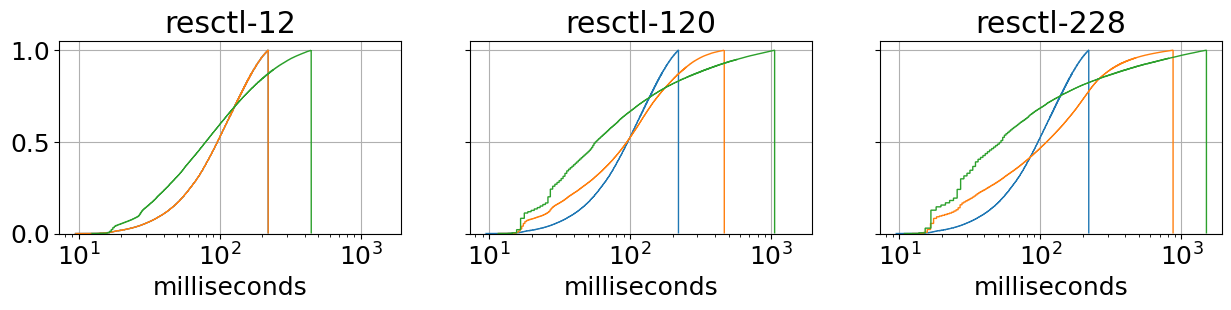

In [32]:
fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_resctl_cfs, results_resctl_cfsllf,fig,ax[0],'resctl-12',12,density=1)
visualise_latency_cdf(results_resctl_cfs, results_resctl_cfsllf,fig,ax[1],'resctl-120',120,density=1)
visualise_latency_cdf(results_resctl_cfs, results_resctl_cfsllf,fig,ax[2],'resctl-228',228,density=1)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,30000)



# Resctl parallel

In [34]:
density_range = [228]


In [35]:
results_resctlparallel_cfs = {}
results_resctlparallel_cfstuned = {}
results_resctlparallel_cfsllf = {}

In [36]:
!sudo cp ../rd-hashd/rd-hashd /usr/local/bin/rd-hashd

print(density_range)

for x in density_range: 
    results_resctlparallel_cfs[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_cfs.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)


print(density_range)

for x in density_range: 
    results_resctlparallel_cfsllf[x] = rd_hashd_experiment(func_count = x,
                                                   llf=True,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_systemd.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)

print(density_range)

for x in density_range: 
    results_resctlparallel_cfstuned[x] = rd_hashd_experiment(func_count = x,
                                                   llf=False,
                                                   duration=100,
                                                   workload='none', script='setup_patch_clean_cfs_tuned.sh',
                                                   schedstats_enabled=False, 
                                                   ftrace_enabled=False)

[228]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #3
ktime                                   : 3510441.791692
sched_clk                               : 3510197.986240
cpu_clk                                 : 3510165.653064
jiffies                                 : 4295769867
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    5076717
dtype: int64

yield                          1932461
schedule                       5983848
idle                             13465
try_to_wake_up                 2435157
try_to_wake_up local           1545226
tasks_running            3204551168097
tasks_waiting           27235616533388
timeslices                     5063171
dtype: int64

[228]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #3
ktime                                   : 3648583.045356
sched_clk                               : 3648337.559946
cpu_clk                                 : 3648305.226753
jiffies                                 : 4295804402
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    3205261
dtype: int64

yield                          1412980
schedule                       4119922
idle                             21236
try_to_wake_up                 1579932
try_to_wake_up local           1128434
tasks_running            3199562658740
tasks_waiting           65602882215284
timeslices                     3185035
dtype: int64

[228]
vm.drop_caches = 3
kernel.sched_energy_aware = 1
kernel.sched_schedstats = 1
-----
24000000
3000000
4000000
750000
Sched Debug Version: v0.11, 5.18.0+ #3
ktime                                   : 3781178.169802
sched_clk                               : 3780931.003893
cpu_clk                                 : 3780898.670695
jiffies                                 : 4295837551
sched_clock_stable()                    : 1

sysctl_sched
  .sysctl_sched_latency                    : 24.000000
  .sysctl_sched_min_granularity            : 3.000000
  .sysctl_sched_idle_min_granularity       : 0.750000
  .sysctl_sched_wakeup_granularity         : 4.000000
  .sysctl_sched_child_runs_first           : 0
  .sysctl_sched_features                   : 29306427
  .sysctl_sched_tunable_scaling            : 1 (logarithmic)

kernel.sched_disable_calc_group_shares = 0
kernel.sched_disable_vruntime_preemption = 0
-----
kernel.sched_entity_before_policy = 0
kernel.sched_check_preempt_wakeup_latency_awar

nr_switches    3215708
dtype: int64

yield                          1680365
schedule                       4016782
idle                              5570
try_to_wake_up                 1490503
try_to_wake_up local           1115720
tasks_running            3206135174567
tasks_waiting           35631745527894
timeslices                     3212298
dtype: int64

In [52]:
variables = [
    ('results_resctlparallel_cfs',results_resctlparallel_cfs),
    ('results_resctlparallel_cfsllf',results_resctlparallel_cfsllf),
    ('results_resctlparallel_cfstuned',results_resctlparallel_cfstuned)
]

dump_vars(variables)


results_resctlparallel_eevdf
results_resctlparallel_eevdfllf


104.13499999999999 249.0
104.13499999999999 249.0
103.55 283.69
104.13499999999999 249.0
381.09 1254.0379999999998
174.43 2890.8539999999957
104.13499999999999 249.0
731.93 1626.0
542.69 3066.673999999999


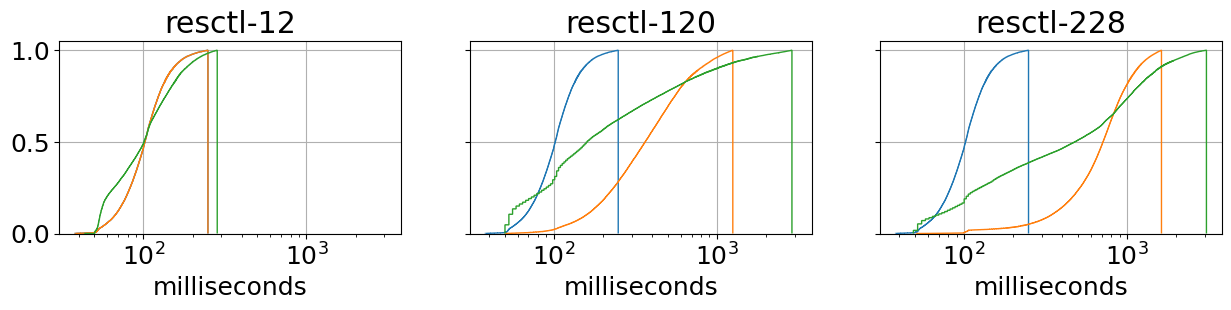

In [55]:


fig, ax = plt.subplots(1,3,figsize=(15,2.5),sharey=True,sharex=True)            

visualise_latency_cdf(results_resctlparallel_eevdf_tuned, results_resctlparallel_eevdfllf,fig,ax[0],'resctl-12',12,density=1)
visualise_latency_cdf(results_resctlparallel_eevdf_tuned, results_resctlparallel_eevdfllf,fig,ax[1],'resctl-120',120,density=1)
visualise_latency_cdf(results_resctlparallel_eevdf_tuned, results_resctlparallel_eevdfllf,fig,ax[2],'resctl-228',228,density=1)

# visualise_latency_cdf(results_notraceclean_cfs, results_notraceclean_llf,fig,ax[2],'resctl',400)

for x in range(3):
    ax[x].set_xscale('log')
    # ax[x].set_xlim(10,30000)

